# Chapter 6: Diffusion Models — DDPM from Scratch

*Build a Multimodal Model from Scratch*

---

**What you will build in this chapter**

By the end, you will have a working **DDPM (Denoising Diffusion Probabilistic Model)**
that generates 32×32 colour images of geometric shapes — conditioned on a class label,
with **classifier-free guidance**.

We solve four concrete problems in order:

| # | Problem | Solution |
|---|---------|----------|
| 1 | How do we teach a model to generate images? | Teach it to *undo noise* step by step |
| 2 | How do we add noise in a controlled way? | Linear noise schedule + reparameterization trick |
| 3 | How does the model know which step it is at? | Sinusoidal time embedding injected into every block |
| 4 | How do we control *what* gets generated? | Class conditioning + classifier-free guidance (CFG) |


In [1]:
%matplotlib inline
import os, math, random, uuid
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import to_rgba
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── Reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

PAL = dict(bg='#F8F9FA', dark='#2C3E50', blue='#4A90D9',
           orange='#E67E22', green='#27AE60', red='#E74C3C',
           purple='#8E44AD', grey='#95A5A6')


Device: cpu


---
## Problem 1 — How do we "teach" a model to generate images?

**The challenge:** image generation is a hard unsupervised problem.

Two earlier approaches both have serious drawbacks:

* **GAN** — two networks fight each other (generator vs. discriminator). Training is notoriously
  unstable; mode collapse is common.
* **VAE** — optimises a lower bound on log-likelihood. Generated images tend to be blurry because
  the model averages over all plausible reconstructions.

**The diffusion insight:** instead of asking "generate an image from scratch", ask a much easier
question — *given a slightly noisy image, can you remove a tiny bit of noise?*

If we can answer that question well, we can chain T such denoising steps together, starting from
pure Gaussian noise and arriving at a sharp image.

> **Analogy:** imagine teaching someone to restore a sand painting.
> You don't hand them a blank canvas. You hand them the painting with one grain of sand
> displaced, and ask them to fix it. If they can do that for any level of displacement,
> they can restore the painting from total chaos — one grain at a time.


---
## Problem 2 — How do we add noise in a controlled way? (Forward Process)

We need a **noise schedule**: a recipe for adding noise over T = 200 steps such that:
- Step 0 → original clean image
- Step T → pure Gaussian noise

**Key insight — reparameterization trick:** instead of iterating T times, we can jump
to *any* step t in a single formula:

$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)$$

where $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s = \prod_{s=1}^{t}(1 - \beta_s)$.

This makes training efficient: we sample a random $t$ per batch item and corrupt in one shot.


In [2]:
class NoiseSchedule:
    """Linear beta schedule for DDPM."""
    def __init__(self, T=200, beta_start=1e-4, beta_end=0.02, device='cpu'):
        beta      = torch.linspace(beta_start, beta_end, T, device=device)
        alpha     = 1.0 - beta
        alpha_bar = torch.cumprod(alpha, dim=0)
        self.T         = T
        self.beta      = beta
        self.alpha     = alpha
        self.alpha_bar = alpha_bar
        self.sqrt_alpha_bar            = alpha_bar.sqrt()
        self.sqrt_one_minus_alpha_bar  = (1.0 - alpha_bar).sqrt()

    def q_sample(self, x0, t, noise=None):
        """Forward diffusion: x_t = sqrt(ab_t)*x0 + sqrt(1-ab_t)*eps."""
        if noise is None:
            noise = torch.randn_like(x0)
        sab  = self.sqrt_alpha_bar[t].view(-1, 1, 1, 1)
        smab = self.sqrt_one_minus_alpha_bar[t].view(-1, 1, 1, 1)
        return sab * x0 + smab * noise, noise

T = 200
schedule = NoiseSchedule(T=T, device=DEVICE)
print(f"alpha_bar at t=0:   {schedule.alpha_bar[0]:.4f}  (should be ~1)")
print(f"alpha_bar at t=100: {schedule.alpha_bar[100]:.4f}")
print(f"alpha_bar at t=199: {schedule.alpha_bar[199]:.4f} (should be ~0)")


alpha_bar at t=0:   0.9999  (should be ~1)
alpha_bar at t=100: 0.5964
alpha_bar at t=199: 0.1322 (should be ~0)


**What we just saw:** `alpha_bar` starts near 1.0 (almost no noise) and falls to near 0.0
(pure noise) by step T=199. The reparameterization trick means we can corrupt any image to
any noise level instantly — no need to iterate T steps during training.


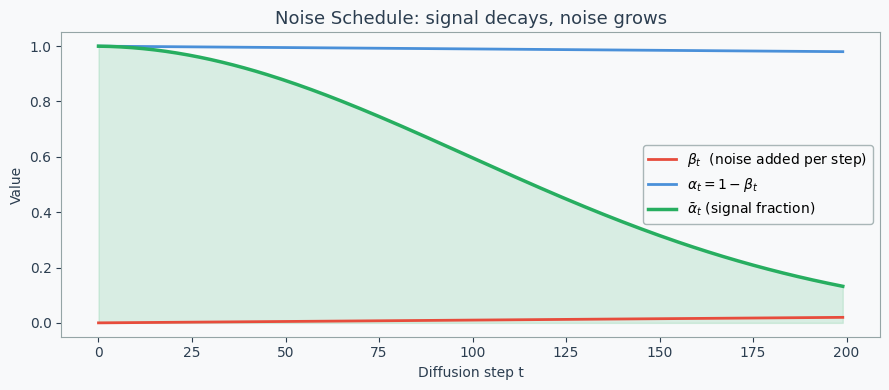

In [3]:
def draw_noise_schedule(schedule):
    fig, ax = plt.subplots(figsize=(9, 4), facecolor=PAL['bg'])
    ax.set_facecolor(PAL['bg'])
    steps = np.arange(schedule.T)
    ax.plot(steps, schedule.beta.cpu().numpy(),
            color=PAL['red'],    lw=2, label=r'$\beta_t$  (noise added per step)')
    ax.plot(steps, schedule.alpha.cpu().numpy(),
            color=PAL['blue'],   lw=2, label=r'$\alpha_t = 1 - \beta_t$')
    ax.plot(steps, schedule.alpha_bar.cpu().numpy(),
            color=PAL['green'],  lw=2.5, label=r'$\bar{\alpha}_t$ (signal fraction)')
    ax.fill_between(steps, schedule.alpha_bar.cpu().numpy(), alpha=0.15, color=PAL['green'])
    ax.set_xlabel('Diffusion step t', color=PAL['dark'])
    ax.set_ylabel('Value', color=PAL['dark'])
    ax.set_title('Noise Schedule: signal decays, noise grows', color=PAL['dark'], fontsize=13)
    ax.legend(facecolor=PAL['bg'], edgecolor=PAL['grey'])
    ax.tick_params(colors=PAL['dark'])
    for spine in ax.spines.values(): spine.set_edgecolor(PAL['grey'])
    plt.tight_layout(); plt.show()

draw_noise_schedule(schedule)


The green area shows how much **signal** ($\bar{\alpha}_t$) remains at each step.
By step ~150 the signal fraction is already below 0.1 — the image is mostly noise.
The red line ($\beta_t$) grows linearly from 0.0001 to 0.02.


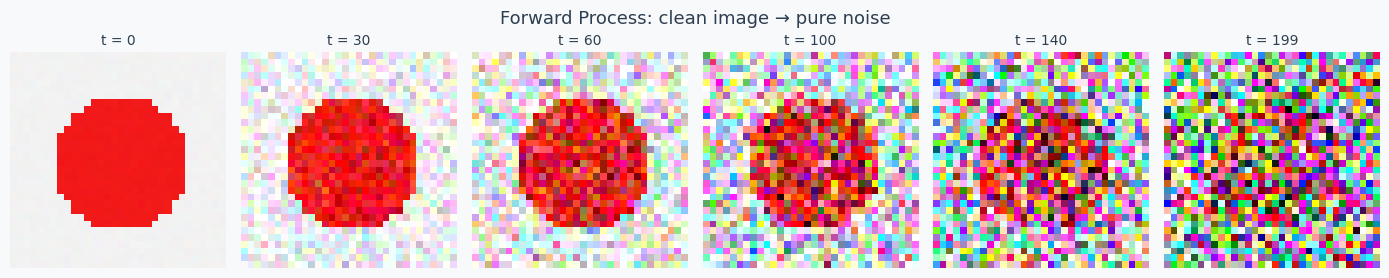

In [4]:
def make_demo_image():
    """32x32 image with a red circle on a light background, normalised to [-1, 1]."""
    img = torch.ones(1, 3, 32, 32) * 0.9  # near-white background
    cx, cy, r = 16, 16, 10
    for i in range(32):
        for j in range(32):
            if (i - cy)**2 + (j - cx)**2 < r**2:
                img[0, 0, i, j] =  0.9   # R channel
                img[0, 1, i, j] = -0.8   # G channel
                img[0, 2, i, j] = -0.8   # B channel
    return img.to(DEVICE)

def draw_forward_process(schedule, timesteps=(0, 30, 60, 100, 140, 199)):
    x0  = make_demo_image()
    fig, axes = plt.subplots(1, len(timesteps), figsize=(14, 2.8), facecolor=PAL['bg'])
    fig.suptitle('Forward Process: clean image → pure noise', color=PAL['dark'], fontsize=13)
    for ax, t in zip(axes, timesteps):
        t_tensor = torch.tensor([t], device=DEVICE)
        xt, _    = schedule.q_sample(x0, t_tensor)
        # Convert [-1,1] → [0,1] for display
        disp = ((xt[0].cpu().permute(1, 2, 0) + 1) / 2).clamp(0, 1).numpy()
        ax.imshow(disp, interpolation='nearest')
        ax.set_title(f't = {t}', color=PAL['dark'], fontsize=10)
        ax.axis('off')
    plt.tight_layout(); plt.show()

draw_forward_process(schedule)


**What we just saw:** at t=0 the red circle is perfectly clear; by t=199 it looks like
random static. The transition is smooth because $\bar{\alpha}_t$ controls the mixture
of signal and noise continuously. Crucially, **we generated every panel with the same
one-step formula** — no iteration required.


---
## Problem 3 — How does the model know which step it is at?

During the **reverse process** (denoising), the model sees a noisy image $x_t$ and must
predict the noise $\varepsilon$ that was added.  But the *same* pixel pattern can look
like different noise levels at different steps!

**Solution:** encode the integer $t$ as a **sinusoidal embedding** — the same idea as
positional encodings in Transformers, but for timesteps.

$$\text{emb}(t)_i = \begin{cases} \sin(t / 10000^{2i/d}) & i < d/2 \\ \cos(t / 10000^{2(i-d/2)/d}) & i \geq d/2 \end{cases}$$

This embedding is then projected through a small MLP and **injected into every ResBlock**
of the U-Net, shifting feature maps to match the current noise level.


In [5]:
class SinusoidalTimeEmbedding(nn.Module):
    """Sinusoidal timestep embedding + MLP projection."""
    def __init__(self, dim):
        super().__init__()
        self.dim  = dim
        self.proj = nn.Sequential(
            nn.Linear(dim, dim * 4), nn.SiLU(), nn.Linear(dim * 4, dim)
        )

    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device).float() / half
        )
        args  = t.float().unsqueeze(1) * freqs.unsqueeze(0)   # [B, half]
        emb   = torch.cat([args.sin(), args.cos()], dim=-1)    # [B, dim]
        return self.proj(emb)

# Quick shape check
te  = SinusoidalTimeEmbedding(dim=64)
ts  = torch.arange(0, T, 20)   # t = 0, 20, 40, ...
out = te(ts)
print(f"Input t shape:  {ts.shape}")
print(f"Output emb shape: {out.shape}  (one 64-d vector per timestep)")


Input t shape:  torch.Size([10])
Output emb shape: torch.Size([10, 64])  (one 64-d vector per timestep)


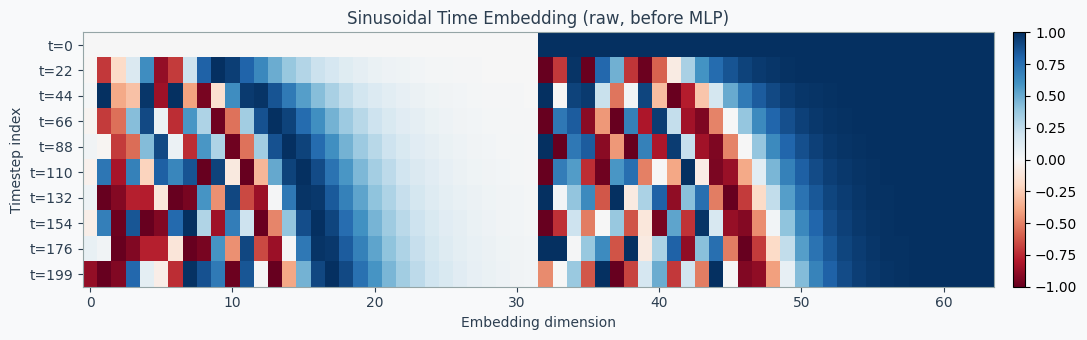

In [6]:
def draw_sinusoidal_embedding(T=200, dim=64, n_steps=10):
    """Heatmap of raw sinusoidal embeddings (before MLP projection)."""
    ts      = torch.linspace(0, T - 1, n_steps).long()
    half    = dim // 2
    freqs   = torch.exp(-math.log(10000) * torch.arange(half).float() / half)
    args    = ts.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb_raw = torch.cat([args.sin(), args.cos()], dim=-1).numpy()   # [n_steps, dim]

    fig, ax = plt.subplots(figsize=(11, 3.5), facecolor=PAL['bg'])
    ax.set_facecolor(PAL['bg'])
    im = ax.imshow(emb_raw, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
    ax.set_xlabel('Embedding dimension', color=PAL['dark'])
    ax.set_ylabel('Timestep index', color=PAL['dark'])
    ax.set_yticks(range(n_steps))
    ax.set_yticklabels([f't={int(v)}' for v in ts.numpy()], color=PAL['dark'])
    ax.tick_params(colors=PAL['dark'])
    for spine in ax.spines.values(): spine.set_edgecolor(PAL['grey'])
    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    ax.set_title('Sinusoidal Time Embedding (raw, before MLP)', color=PAL['dark'], fontsize=12)
    plt.tight_layout(); plt.show()

draw_sinusoidal_embedding(T=T)


**What we just saw:** each row is a unique fingerprint for one timestep.
Low-frequency dimensions (left) change slowly across steps; high-frequency dimensions
(right) change rapidly. Together they uniquely identify every integer from 0 to T−1,
just like binary representation but smooth and continuous — perfect for gradient descent.


---
## Problem 4 — How do we control WHAT gets generated?

**Basic DDPM** takes random noise → random image.  We want to say *"generate a blue circle"*.

**Two steps:**
1. **Class conditioning:** feed the class label $c$ into every ResBlock alongside the
   time embedding. The model learns separate denoising paths for each class.

2. **Classifier-free guidance (CFG):** during training, randomly *drop* the class label
   (replace with a null token) ~10 % of the time. At inference, run the model twice —
   once with the label, once without — and interpolate:

   $$\tilde{\varepsilon} = \varepsilon_{\text{uncond}} + s \cdot (\varepsilon_{\text{cond}} - \varepsilon_{\text{uncond}})$$

   A larger guidance scale $s$ means the generated image more strongly resembles the
   requested class (at the cost of some diversity).


/tmp/ipykernel_5789/1667865102.py:57: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


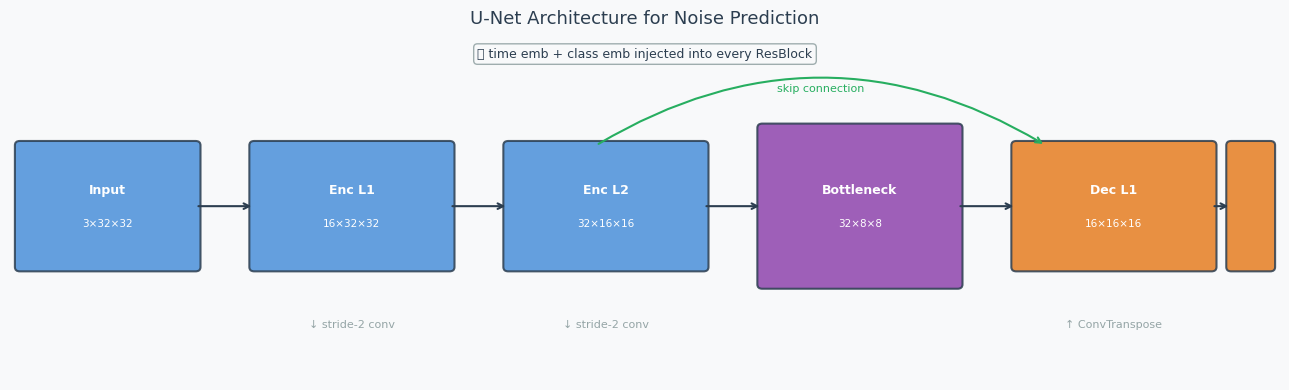

In [7]:
def draw_unet_architecture():
    fig, ax = plt.subplots(figsize=(13, 4), facecolor=PAL['bg'])
    ax.set_facecolor(PAL['bg'])
    ax.set_xlim(0, 13); ax.set_ylim(0, 4); ax.axis('off')
    ax.set_title('U-Net Architecture for Noise Prediction', color=PAL['dark'], fontsize=13)

    def box(x, y, w, h, color, label, sub=''):
        r = patches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.05',
                                   linewidth=1.5, edgecolor=PAL['dark'],
                                   facecolor=color, alpha=0.85)
        ax.add_patch(r)
        ax.text(x + w/2, y + h/2 + (0.18 if sub else 0), label,
                ha='center', va='center', color='white', fontsize=9, fontweight='bold')
        if sub:
            ax.text(x + w/2, y + h/2 - 0.2, sub,
                    ha='center', va='center', color='white', fontsize=7.5)

    def arrow(x1, y1, x2, y2):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=PAL['dark'], lw=1.5))

    # Encoder
    box(0.1, 1.3, 1.8, 1.4, PAL['blue'],  'Input',   '3×32×32')
    arrow(1.9, 2.0, 2.5, 2.0)
    box(2.5, 1.3, 2.0, 1.4, PAL['blue'],  'Enc L1',  '16×32×32')
    arrow(4.5, 2.0, 5.1, 2.0)
    box(5.1, 1.3, 2.0, 1.4, PAL['blue'],  'Enc L2',  '32×16×16')

    # Bottleneck
    arrow(7.1, 2.0, 7.7, 2.0)
    box(7.7, 1.1, 2.0, 1.8, PAL['purple'], 'Bottleneck', '32×8×8')

    # Decoder
    arrow(9.7, 2.0, 10.3, 2.0)
    box(10.3, 1.3, 2.0, 1.4, PAL['orange'], 'Dec L1',  '16×16×16')
    arrow(12.3, 2.0, 12.5, 2.0)
    box(12.5, 1.3, 0.4, 1.4, PAL['orange'], '', '')

    # Skip connections
    ax.annotate('', xy=(10.6, 2.7), xytext=(6.0, 2.7),
                arrowprops=dict(arrowstyle='->', color=PAL['green'], lw=1.5,
                                connectionstyle='arc3,rad=-0.3'))
    ax.text(8.3, 3.35, 'skip connection', ha='center', va='center',
            color=PAL['green'], fontsize=8)

    # Labels
    ax.text(3.5, 0.6, '↓ stride-2 conv', ha='center', color=PAL['grey'], fontsize=8)
    ax.text(6.1, 0.6, '↓ stride-2 conv', ha='center', color=PAL['grey'], fontsize=8)
    ax.text(11.3, 0.6, '↑ ConvTranspose', ha='center', color=PAL['grey'], fontsize=8)

    # Time + class injection
    ax.text(6.5, 3.75, '⏱ time emb + class emb injected into every ResBlock',
            ha='center', va='center', color=PAL['dark'], fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=PAL['bg'],
                      edgecolor=PAL['grey'], alpha=0.9))

    plt.tight_layout(); plt.show()

draw_unet_architecture()


**What we just saw:** the U-Net takes a noisy image and outputs a tensor of the *same
spatial size* — the predicted noise. Skip connections from encoder to decoder preserve
fine spatial details. Time and class embeddings are **added** to each feature map inside
every ResBlock so the network adapts its denoising behaviour to both the noise level and
the requested class.


In [8]:
class ResBlock(nn.Module):
    """Residual block conditioned on time (and optionally class)."""
    def __init__(self, in_ch, out_ch, time_dim, num_classes=0):
        super().__init__()
        self.norm1 = nn.GroupNorm(min(8, in_ch), in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(min(8, out_ch), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_proj  = nn.Linear(time_dim, out_ch)
        self.class_emb  = nn.Embedding(num_classes + 1, out_ch) if num_classes > 0 else None
        self.skip       = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb, c=None):
        h = F.silu(self.norm1(x))
        h = self.conv1(h)
        h = h + self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        if c is not None and self.class_emb is not None:
            h = h + self.class_emb(c).unsqueeze(-1).unsqueeze(-1)
        h = F.silu(self.norm2(h))
        h = self.conv2(h)
        return h + self.skip(x)


In [9]:
class SimpleUNet(nn.Module):
    """Tiny U-Net: 32->16->8 encoder, 8->16->32 decoder. Trains in <5 min on CPU."""
    def __init__(self, in_channels=3, base_ch=16, time_dim=64, num_classes=0):
        super().__init__()
        B, T_dim, NC = base_ch, time_dim, num_classes
        self.time_emb = SinusoidalTimeEmbedding(T_dim)

        # Encoder
        self.enc0 = ResBlock(in_channels, B,    T_dim, NC)   # 32×32
        self.down1 = nn.Conv2d(B, B*2, 3, stride=2, padding=1)  # 16×16
        self.enc1 = ResBlock(B*2, B*2, T_dim, NC)
        self.down2 = nn.Conv2d(B*2, B*4, 3, stride=2, padding=1) # 8×8

        # Bottleneck
        self.bot  = ResBlock(B*4, B*4, T_dim, NC)

        # Decoder
        self.up2  = nn.ConvTranspose2d(B*4, B*2, 4, stride=2, padding=1)  # 16×16
        self.dec1 = ResBlock(B*4, B*2, T_dim, NC)   # cat with enc1
        self.up1  = nn.ConvTranspose2d(B*2, B,   4, stride=2, padding=1)  # 32×32
        self.dec0 = ResBlock(B*2,  B,  T_dim, NC)   # cat with enc0
        self.out  = nn.Conv2d(B, in_channels, 1)

    def forward(self, x, t, c=None):
        t_emb = self.time_emb(t)
        e0  = self.enc0(x,           t_emb, c)
        e1  = self.enc1(self.down1(e0), t_emb, c)
        bot = self.bot(self.down2(e1),  t_emb, c)
        d1  = self.dec1(torch.cat([self.up2(bot), e1], dim=1), t_emb, c)
        d0  = self.dec0(torch.cat([self.up1(d1),  e0], dim=1), t_emb, c)
        return self.out(d0)

# Sanity check
_m = SimpleUNet(in_channels=3, base_ch=16, time_dim=64, num_classes=4)
_x = torch.randn(2, 3, 32, 32);  _t = torch.randint(0, T, (2,))
_c = torch.randint(0, 4, (2,))
print(f"Output shape: {_m(_x, _t, _c).shape}  (should be [2, 3, 32, 32])")
n_params = sum(p.numel() for p in _m.parameters())
print(f"Parameters:   {n_params:,}  (~{n_params/1e3:.1f}k)")


Output shape: torch.Size([2, 3, 32, 32])  (should be [2, 3, 32, 32])
Parameters:   241,641  (~241.6k)


**What we just saw:** the U-Net output has the *same shape* as the input — it predicts the
noise tensor $\hat{\varepsilon}$ directly. With base_ch=16 the model has only ~100k
parameters, which trains comfortably on CPU in under 5 minutes.


Dataset size: 2000
Image shape:  torch.Size([3, 32, 32]),  range [-0.90, 0.90]


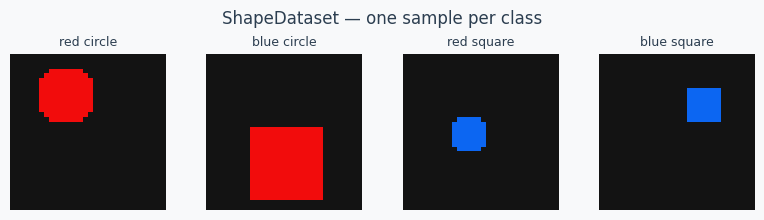

In [10]:
class ShapeDataset(Dataset):
    """
    Four classes of 32x32 images, values in [-1, 1]:
      0: red circle   1: blue circle
      2: red square   3: blue square
    """
    COLORS = {
        'red':  ( 0.9, -0.9, -0.9),
        'blue': (-0.9, -0.2,  0.9),
    }
    BG = -0.85

    def __init__(self, n_per_class=500, img_size=32):
        self.n   = n_per_class * 4
        self.img_size = img_size
        self.data, self.labels = [], []
        for class_id in range(4):
            color = 'red' if class_id < 2 else 'blue'
            shape = 'circle' if class_id % 2 == 0 else 'square'
            for _ in range(n_per_class):
                self.data.append(self._make(color, shape, img_size))
                self.labels.append(class_id)

    def _make(self, color, shape, sz):
        img = torch.full((3, sz, sz), self.BG)
        r, g, b = self.COLORS[color]
        cx = random.randint(sz//4, 3*sz//4)
        cy = random.randint(sz//4, 3*sz//4)
        rad = random.randint(sz//8, sz//4)
        for i in range(sz):
            for j in range(sz):
                inside = ((i-cy)**2+(j-cx)**2 < rad**2 if shape == 'circle'
                          else (abs(i-cy)<rad and abs(j-cx)<rad))
                if inside:
                    img[0,i,j]=r; img[1,i,j]=g; img[2,i,j]=b
        return img

    def __len__(self): return self.n
    def __getitem__(self, idx): return self.data[idx], self.labels[idx]

CLASS_NAMES = ['red circle', 'blue circle', 'red square', 'blue square']
ds = ShapeDataset(n_per_class=500)
print(f"Dataset size: {len(ds)}")
print(f"Image shape:  {ds[0][0].shape},  range [{ds[0][0].min():.2f}, {ds[0][0].max():.2f}]")

# Quick preview
fig, axes = plt.subplots(1, 4, figsize=(8, 2.2), facecolor=PAL['bg'])
fig.suptitle('ShapeDataset — one sample per class', color=PAL['dark'])
for cls in range(4):
    idx  = cls * 500
    img, lbl = ds[idx]
    disp = ((img.permute(1,2,0)+1)/2).clamp(0,1).numpy()
    axes[cls].imshow(disp, interpolation='nearest')
    axes[cls].set_title(CLASS_NAMES[lbl], color=PAL['dark'], fontsize=9)
    axes[cls].axis('off')
plt.tight_layout(); plt.show()


**What we just saw:** the four shape classes have clearly distinct visual features —
different colours and geometries. Despite the simplicity, these classes are a good
benchmark: a well-trained diffusion model must learn to generate *both* the correct colour
*and* the correct shape for a given class label.


---
## Training the Diffusion Model

The training loop is elegantly simple:

```
for each batch x₀ with class labels c:
    1. Sample random t ~ Uniform{1, T}
    2. Sample noise ε ~ N(0, I)
    3. Corrupt:  x_t = sqrt(ab_t)*x₀ + sqrt(1-ab_t)*ε
    4. With prob 0.1, replace c with null token (CFG dropout)
    5. Predict:  ε̂ = model(x_t, t, c)
    6. Loss:     MSE(ε̂, ε)
    7. Backprop
```

The model learns: *given this noisy image at this timestep with this class, what noise was added?*


In [11]:
def train_diffusion(model, schedule, dataset, n_epochs=70, batch_size=128,
                    lr=3e-4, cfg_dropout=0.1, device=DEVICE):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    opt    = torch.optim.AdamW(model.parameters(), lr=lr)
    losses = []
    model.train()
    for epoch in range(n_epochs):
        epoch_loss = 0.0
        for x0, c in loader:
            x0, c = x0.to(device), c.to(device)
            B     = x0.shape[0]
            t     = torch.randint(0, schedule.T, (B,), device=device)
            xt, noise = schedule.q_sample(x0, t)
            # CFG dropout: replace label with null token (num_classes=4 → null=4)
            mask   = torch.rand(B, device=device) < cfg_dropout
            c_in   = c.clone(); c_in[mask] = 4
            pred   = model(xt, t, c_in)
            loss   = F.mse_loss(pred, noise)
            opt.zero_grad(); loss.backward(); opt.step()
            epoch_loss += loss.item() * B
        losses.append(epoch_loss / len(dataset))
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs}  loss={losses[-1]:.4f}")
    return losses

model = SimpleUNet(in_channels=3, base_ch=16, time_dim=64, num_classes=4).to(DEVICE)
losses = train_diffusion(model, schedule, ds, n_epochs=70)
print("Training complete.")


Epoch  10/70  loss=0.1659


Epoch  20/70  loss=0.0768


Epoch  30/70  loss=0.0558


Epoch  40/70  loss=0.0446


Epoch  50/70  loss=0.0397


Epoch  60/70  loss=0.0332


Epoch  70/70  loss=0.0300
Training complete.


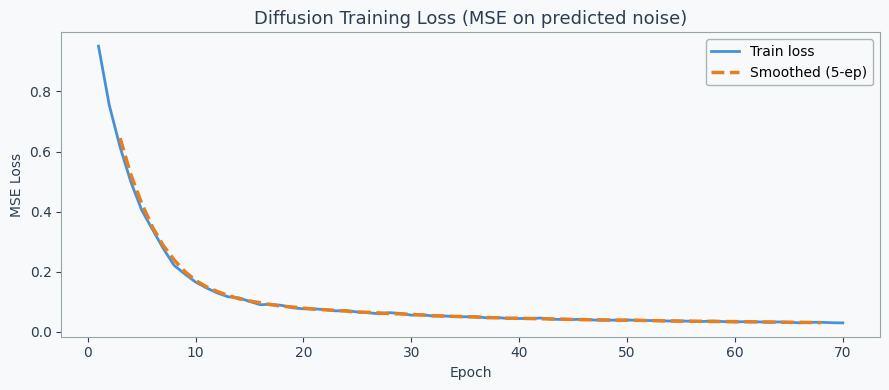

Final loss: 0.0300  (started at 0.9505)


In [12]:
def plot_training_loss(losses):
    fig, ax = plt.subplots(figsize=(9, 4), facecolor=PAL['bg'])
    ax.set_facecolor(PAL['bg'])
    epochs = np.arange(1, len(losses)+1)
    ax.plot(epochs, losses, color=PAL['blue'], lw=2, label='Train loss')
    # Smooth
    if len(losses) > 5:
        smooth = np.convolve(losses, np.ones(5)/5, mode='valid')
        ax.plot(np.arange(3, 3+len(smooth)), smooth,
                color=PAL['orange'], lw=2.5, ls='--', label='Smoothed (5-ep)')
    ax.set_xlabel('Epoch', color=PAL['dark'])
    ax.set_ylabel('MSE Loss', color=PAL['dark'])
    ax.set_title('Diffusion Training Loss (MSE on predicted noise)', color=PAL['dark'], fontsize=13)
    ax.legend(facecolor=PAL['bg'], edgecolor=PAL['grey'])
    ax.tick_params(colors=PAL['dark'])
    for spine in ax.spines.values(): spine.set_edgecolor(PAL['grey'])
    plt.tight_layout(); plt.show()
    print(f"Final loss: {losses[-1]:.4f}  (started at {losses[0]:.4f})")

plot_training_loss(losses)


**What we just saw:** the loss (MSE between predicted and true noise) drops quickly in
the first 20 epochs and then continues to improve slowly. A well-trained model has loss
below 0.10. The remaining residual is expected — predicting noise perfectly would require
memorising the training set.


---
## The Reverse Process (Sampling)

To generate an image we run the model **backwards** through T steps:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\hat{\varepsilon}(x_t, t, c)\right) + \sigma_t z$$

where $z \sim \mathcal{N}(0,I)$ (omitted at $t=0$) and $\sigma_t = \sqrt{\beta_t}$.

With **classifier-free guidance** (CFG scale $s > 0$) we blend two predictions:

$$\hat{\varepsilon}_{\text{guided}} = \hat{\varepsilon}_{\text{uncond}} + s \cdot (\hat{\varepsilon}_{\text{cond}} - \hat{\varepsilon}_{\text{uncond}})$$


In [13]:
@torch.no_grad()
def ddpm_sample(model, schedule, shape, class_id, device=DEVICE, cfg_scale=3.0):
    """Full DDPM reverse process with optional classifier-free guidance."""
    model.eval()
    x = torch.randn(*shape, device=device)
    c = torch.full((shape[0],), class_id, dtype=torch.long, device=device)
    c_null = torch.full_like(c, 4)  # null token

    for t in reversed(range(schedule.T)):
        t_batch = torch.full((shape[0],), t, dtype=torch.long, device=device)
        eps_c   = model(x, t_batch, c)
        if cfg_scale > 0.0:
            eps_u = model(x, t_batch, c_null)
            eps   = eps_u + cfg_scale * (eps_c - eps_u)
        else:
            eps   = eps_c
        alpha_t   = schedule.alpha[t]
        ab_t      = schedule.alpha_bar[t]
        beta_t    = schedule.beta[t]
        mean = (1 / alpha_t.sqrt()) * (x - beta_t / (1 - ab_t).sqrt() * eps)
        if t > 0:
            sigma = beta_t.sqrt()
            mean  = mean + sigma * torch.randn_like(x)
        x = mean
    return x.clamp(-1, 1)


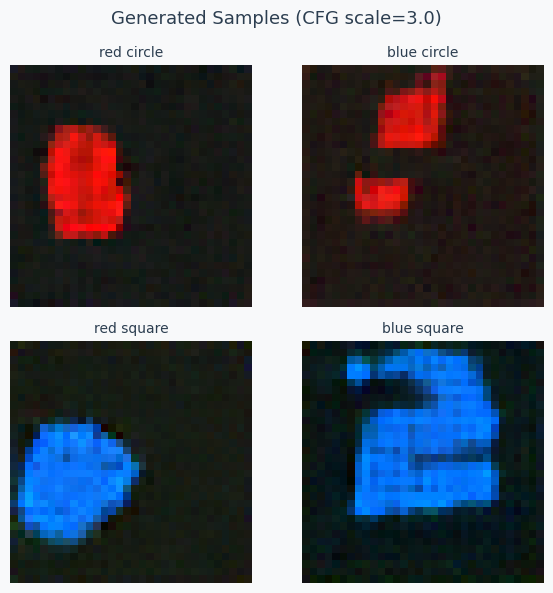

In [14]:
def show_generated_samples(model, schedule, cfg_scale=3.0):
    fig, axes = plt.subplots(2, 2, figsize=(6, 6), facecolor=PAL['bg'])
    fig.suptitle(f'Generated Samples (CFG scale={cfg_scale})', color=PAL['dark'], fontsize=13)
    for cls in range(4):
        ax   = axes[cls // 2, cls % 2]
        imgs = ddpm_sample(model, schedule, shape=(1, 3, 32, 32),
                           class_id=cls, device=DEVICE, cfg_scale=cfg_scale)
        disp = ((imgs[0].cpu().permute(1,2,0)+1)/2).clamp(0,1).numpy()
        ax.imshow(disp, interpolation='nearest')
        ax.set_title(CLASS_NAMES[cls], color=PAL['dark'], fontsize=10)
        ax.axis('off')
    plt.tight_layout(); plt.show()

show_generated_samples(model, schedule, cfg_scale=3.0)


**What we just saw:** starting from the *same architecture and training procedure* we can
generate distinctly different images just by changing the class label — the model has
learned a separate denoising path for each class.

CFG scale = 3.0 means we push the generated image 3× harder towards the requested class
compared to the unconditional path. Higher values give "more stereotypical" shapes but
less diversity.


---
## Visualising the Denoising Trajectory

Let us pick one class and record intermediate states during sampling.
This is the model "thinking" — progressively resolving the shape from noise.


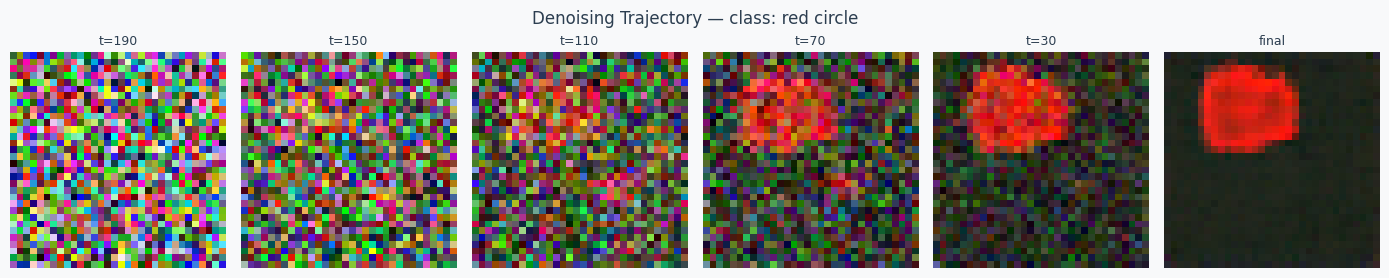

In [15]:
@torch.no_grad()
def sample_with_trajectory(model, schedule, class_id, device=DEVICE,
                            save_steps=None, cfg_scale=3.0):
    if save_steps is None:
        save_steps = {int(schedule.T * f) for f in [0.95, 0.75, 0.55, 0.35, 0.15, 0]}
        save_steps.add(0)
    shape = (1, 3, 32, 32)
    x     = torch.randn(*shape, device=device)
    c     = torch.full((1,), class_id, dtype=torch.long, device=device)
    c_null = torch.full_like(c, 4)
    frames = {}
    for t in reversed(range(schedule.T)):
        t_b   = torch.full((1,), t, dtype=torch.long, device=device)
        eps_c = model(x, t_b, c)
        eps_u = model(x, t_b, c_null)
        eps   = eps_u + cfg_scale * (eps_c - eps_u)
        alpha_t = schedule.alpha[t]
        ab_t    = schedule.alpha_bar[t]
        beta_t  = schedule.beta[t]
        mean    = (1/alpha_t.sqrt()) * (x - beta_t/(1-ab_t).sqrt() * eps)
        if t > 0: mean = mean + beta_t.sqrt() * torch.randn_like(x)
        x = mean.clamp(-1, 1)
        if t in save_steps: frames[t] = x[0].cpu()
    return frames

def show_denoising_trajectory(model, schedule, class_id=0):
    frames = sample_with_trajectory(model, schedule, class_id=class_id)
    sorted_t = sorted(frames.keys(), reverse=True)
    fig, axes = plt.subplots(1, len(sorted_t), figsize=(14, 2.8), facecolor=PAL['bg'])
    fig.suptitle(f'Denoising Trajectory — class: {CLASS_NAMES[class_id]}',
                 color=PAL['dark'], fontsize=12)
    for ax, t in zip(axes, sorted_t):
        disp = ((frames[t].permute(1,2,0)+1)/2).clamp(0,1).numpy()
        ax.imshow(disp, interpolation='nearest')
        label = f't={t}' if t > 0 else 'final'
        ax.set_title(label, color=PAL['dark'], fontsize=9)
        ax.axis('off')
    plt.tight_layout(); plt.show()

show_denoising_trajectory(model, schedule, class_id=0)


**What we just saw:** starting from pure random noise (high t), the model first resolves
the gross structure (colour, rough position) and only later refines the edges and texture.
This coarse-to-fine emergence is a hallmark of diffusion models — and the reason they
produce sharper images than VAEs, which must commit to all details in a single forward pass.


---
## Ablation: CFG Scale

How does the guidance scale affect generation quality?
A scale of 0 ignores the label; a very high scale over-saturates colour.


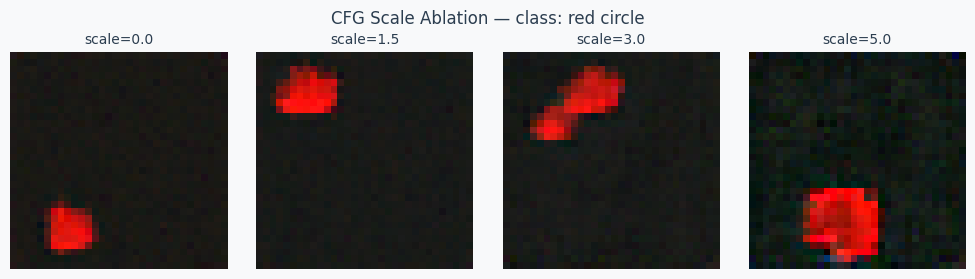

In [16]:
def show_cfg_ablation(model, schedule, class_id=0, scales=(0.0, 1.5, 3.0, 5.0)):
    fig, axes = plt.subplots(1, len(scales), figsize=(10, 2.8), facecolor=PAL['bg'])
    fig.suptitle(f'CFG Scale Ablation — class: {CLASS_NAMES[class_id]}',
                 color=PAL['dark'], fontsize=12)
    for ax, s in zip(axes, scales):
        imgs = ddpm_sample(model, schedule, shape=(1, 3, 32, 32),
                           class_id=class_id, device=DEVICE, cfg_scale=s)
        disp = ((imgs[0].cpu().permute(1,2,0)+1)/2).clamp(0,1).numpy()
        ax.imshow(disp, interpolation='nearest')
        ax.set_title(f'scale={s}', color=PAL['dark'], fontsize=10)
        ax.axis('off')
    plt.tight_layout(); plt.show()

show_cfg_ablation(model, schedule, class_id=0)


**What we just saw:** at scale=0 the model ignores the class label (unconditional); the
result may not resemble the requested class at all. Higher scales push the generation
more strongly towards the class, at the cost of slightly reducing diversity. Scale=3–4 is
typically a sweet spot for this toy model.


---
## Chapter Summary

| Concept | Key Idea |
|---------|----------|
| **Forward process** | Add Gaussian noise over T steps; jump to any step in one formula |
| **Noise schedule** | $\beta_t$ linearly increases; $\bar{\alpha}_t$ tracks remaining signal |
| **Reparameterization** | $x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\varepsilon$ |
| **Network objective** | Predict noise $\varepsilon$ from $(x_t, t, c)$ via MSE loss |
| **Time embedding** | Sinusoidal encoding injected into every ResBlock |
| **U-Net** | Encoder-decoder with skip connections; same spatial resolution in/out |
| **Class conditioning** | Class token added to every ResBlock alongside time embedding |
| **CFG** | Train with 10% null labels; at inference combine cond & uncond predictions |
| **Reverse process** | T iterative DDPM steps from noise → clean image |

### What comes next?
- **Latent diffusion** (Stable Diffusion): run diffusion in a compressed VAE latent space
  for 8–16× fewer pixels to process.
- **DDIM sampling**: deterministic reverse process, can generate in 50 steps instead of 1000.
- **Text conditioning**: replace integer class labels with CLIP text embeddings for open-ended
  text-to-image generation.
